# Compare Fine-Tuned vs Encoder-Only on Rotten Tomatoes

This notebook evaluates your two saved sentiment models on the Hugging Face dataset `cornell-movie-review-data/rotten_tomatoes`.

In [2]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)
from transformers import AutoTokenizer, AutoModelForSequenceClassification

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

LOCAL_DIR = Path.cwd()
FINE_TUNED_DIR = LOCAL_DIR / "merged_model"
ENCODER_CKPT = LOCAL_DIR / "best_model.pt"
ENCODER_TOKENIZER_PATH = LOCAL_DIR / "word_tokenizer.json"

required_paths = [FINE_TUNED_DIR, ENCODER_CKPT, ENCODER_TOKENIZER_PATH]
missing = [str(p) for p in required_paths if not p.exists()]
if missing:
    msg = "Expected all model files in local directory. Missing:\n- " + "\n- ".join(missing)
    raise FileNotFoundError(msg)

print(f"Local dir         : {LOCAL_DIR.resolve()}")
print(f"Fine-tuned model  : {FINE_TUNED_DIR}")
print(f"Encoder checkpoint: {ENCODER_CKPT}")
print(f"Encoder tokenizer : {ENCODER_TOKENIZER_PATH}")

Device: cuda
Local dir         : /content
Fine-tuned model  : /content/merged_model
Encoder checkpoint: /content/best_model.pt
Encoder tokenizer : /content/word_tokenizer.json


In [3]:
from datasets import load_dataset, concatenate_datasets

dataset_dict = load_dataset("cornell-movie-review-data/rotten_tomatoes")

# Concatenate all splits
if isinstance(dataset_dict, dict):
    all_splits = [dataset_dict[split] for split in dataset_dict.keys()]
    eval_split = concatenate_datasets(all_splits)
    split_name = "entire_dataset"
else:
    # If dataset_dict is already a single dataset (e.g., if there's only one split)
    eval_split = dataset_dict
    split_name = "default_split" # Or get the actual split name if possible

text_col_candidates = ["text", "review", "sentence"]
label_col_candidates = ["label", "labels", "sentiment"]

text_col = next((c for c in eval_split.column_names if c in text_col_candidates), None)
label_col = next((c for c in eval_split.column_names if c in label_col_candidates), None)

if text_col is None or label_col is None:
    raise ValueError(f"Could not infer text/label columns from {eval_split.column_names}")

texts = eval_split[text_col]
y_true = np.array(eval_split[label_col], dtype=np.int64)

print(f"Loaded split '{split_name}' with {len(texts):,} reviews")
print(f"Columns: {eval_split.column_names}")
labels, counts = np.unique(y_true, return_counts=True)
print("Label distribution:", dict(zip(labels.tolist(), counts.tolist())))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.parquet:   0%|          | 0.00/699k [00:00<?, ?B/s]

validation.parquet:   0%|          | 0.00/90.0k [00:00<?, ?B/s]

test.parquet:   0%|          | 0.00/92.2k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8530 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1066 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1066 [00:00<?, ? examples/s]

Loaded split 'entire_dataset' with 10,662 reviews
Columns: ['text', 'label']
Label distribution: {0: 5331, 1: 5331}


In [4]:
CONFIG = dict(
    seed=42,
    max_len=384,
    vocab_size=30_000,
    d_model=512,
    n_heads=8,
    n_layers=6,
    dim_ff=2048,
    dropout=0.15,
    pooling="mean",
)

def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z\\s]", " ", text)
    text = re.sub(r"\\s+", " ", text).strip()
    return text

class WordTokenizer:
    PAD, UNK, CLS, EOS = "<pad>", "<unk>", "<cls>", "<eos>"
    SPECIAL = [PAD, UNK, CLS, EOS]

    def __init__(self, token2id: dict, vocab_size: int = None):
        self.token2id = token2id
        self.id2token = {v: k for k, v in token2id.items()}
        self.vocab_size = vocab_size if vocab_size is not None else len(token2id)

    @classmethod
    def from_json(cls, path: Path):
        with path.open("r", encoding="utf-8") as f:
            data = json.load(f)
        return cls(token2id=data["token2id"], vocab_size=data.get("vocab_size"))

    def encode(self, text: str, max_len: int) -> list:
        unk = self.token2id[self.UNK]
        ids = [self.token2id[self.CLS]]
        for w in text.split():
            ids.append(self.token2id.get(w, unk))
        ids.append(self.token2id[self.EOS])
        if len(ids) > max_len:
            ids = ids[: max_len - 1] + [self.token2id[self.EOS]]
        return ids

    @property
    def pad_id(self):
        return self.token2id[self.PAD]

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.attn_drop = nn.Dropout(dropout)

    def forward(self, x, mask):
        bsz, seq_len, d_model = x.shape
        qkv = self.qkv(x).reshape(bsz, seq_len, 3, self.n_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.masked_fill(mask[:, None, None, :] == 0, float("-inf"))
        attn = self.attn_drop(attn.softmax(dim=-1))

        out = (attn @ v).transpose(1, 2).reshape(bsz, seq_len, d_model)
        return self.out_proj(out)

class FeedForward(nn.Module):
    def __init__(self, d_model, dim_ff, dropout):
        super().__init__()
        self.fc1 = nn.Linear(d_model, dim_ff)
        self.fc2 = nn.Linear(dim_ff, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        return self.fc2(self.drop(F.gelu(self.fc1(x))))

class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, dim_ff, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model, dim_ff, dropout)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask):
        x = x + self.drop(self.attn(self.ln1(x), mask))
        x = x + self.drop(self.ff(self.ln2(x)))
        return x

class SentimentTransformer(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.pooling = cfg["pooling"]
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["d_model"], padding_idx=0)
        self.pos_emb = nn.Embedding(cfg["max_len"], cfg["d_model"])
        self.emb_drop = nn.Dropout(cfg["dropout"])
        self.blocks = nn.ModuleList([
            TransformerBlock(cfg["d_model"], cfg["n_heads"], cfg["dim_ff"], cfg["dropout"])
            for _ in range(cfg["n_layers"])
        ])
        self.final_ln = nn.LayerNorm(cfg["d_model"])
        self.head = nn.Sequential(
            nn.LayerNorm(cfg["d_model"]),
            nn.Dropout(cfg["dropout"]),
            nn.Linear(cfg["d_model"], 2),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.padding_idx is not None:
                    m.weight.data[m.padding_idx].zero_()
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, input_ids, mask):
        batch_size, seq_len = input_ids.shape
        pos = torch.arange(seq_len, device=input_ids.device).unsqueeze(0)
        x = self.emb_drop(self.tok_emb(input_ids) + self.pos_emb(pos))
        for blk in self.blocks:
            x = blk(x, mask)
        x = self.final_ln(x)
        if self.pooling == "cls":
            pooled = x[:, 0]
        else:
            mask_f = mask.unsqueeze(-1).float()
            pooled = (x * mask_f).sum(1) / mask_f.sum(1).clamp(min=1e-9)
        return self.head(pooled)

encoder_tokenizer = WordTokenizer.from_json(ENCODER_TOKENIZER_PATH)
print(f"Encoder tokenizer vocab size: {len(encoder_tokenizer.token2id):,}")

Encoder tokenizer vocab size: 30,000


In [5]:
fine_tuned_tokenizer = AutoTokenizer.from_pretrained(FINE_TUNED_DIR)
fine_tuned_model = AutoModelForSequenceClassification.from_pretrained(FINE_TUNED_DIR).to(DEVICE)
fine_tuned_model.eval()

encoder_model = SentimentTransformer(CONFIG).to(DEVICE)
state_dict = torch.load(ENCODER_CKPT, map_location=DEVICE)
if isinstance(state_dict, dict) and "state_dict" in state_dict:
    state_dict = state_dict["state_dict"]
if any(k.startswith("module.") for k in state_dict.keys()):
    state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}
encoder_model.load_state_dict(state_dict, strict=True)
encoder_model.eval()

print("Loaded both models successfully.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded both models successfully.


In [6]:
def batched(items, batch_size):
    for i in range(0, len(items), batch_size):
        yield items[i : i + batch_size]

@torch.no_grad()
def predict_fine_tuned(texts, batch_size=32, max_len=512):
    preds, pos_probs = [], []
    for batch_texts in batched(texts, batch_size):
        encoded = fine_tuned_tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors="pt",
        ).to(DEVICE)
        logits = fine_tuned_model(**encoded).logits
        probs = torch.softmax(logits, dim=-1)
        preds.extend(logits.argmax(dim=-1).cpu().tolist())
        pos_probs.extend(probs[:, 1].cpu().tolist())
    return np.array(preds), np.array(pos_probs)

@torch.no_grad()
def predict_encoder_only(texts, batch_size=64):
    preds, pos_probs = [], []
    for batch_texts in batched(texts, batch_size):
        encoded_texts = [encoder_tokenizer.encode(clean_text(t), CONFIG["max_len"]) for t in batch_texts]
        max_len = max(len(ids) for ids in encoded_texts)
        input_ids = torch.full(
            (len(encoded_texts), max_len),
            encoder_tokenizer.pad_id,
            dtype=torch.long,
            device=DEVICE,
        )
        mask = torch.zeros((len(encoded_texts), max_len), dtype=torch.long, device=DEVICE)
        for idx, ids in enumerate(encoded_texts):
            seq = torch.tensor(ids, dtype=torch.long, device=DEVICE)
            input_ids[idx, : len(ids)] = seq
            mask[idx, : len(ids)] = 1

        logits = encoder_model(input_ids, mask)
        probs = torch.softmax(logits, dim=-1)
        preds.extend(logits.argmax(dim=-1).cpu().tolist())
        pos_probs.extend(probs[:, 1].cpu().tolist())
    return np.array(preds), np.array(pos_probs)

def summarize_metrics(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

ft_pred, ft_prob = predict_fine_tuned(texts)
enc_pred, enc_prob = predict_encoder_only(texts)

rows = [
    {"model": "Fine-tuned (LoRA merged BERT)", **summarize_metrics(y_true, ft_pred)},
    {"model": "Encoder-only (from scratch)", **summarize_metrics(y_true, enc_pred)},
]
results_df = pd.DataFrame(rows).set_index("model")
display(results_df.style.format("{:.4f}"))

print("\nFine-tuned confusion matrix:")
print(confusion_matrix(y_true, ft_pred))
print("\nEncoder-only confusion matrix:")
print(confusion_matrix(y_true, enc_pred))

print("\nFine-tuned classification report:")
print(classification_report(y_true, ft_pred, digits=4))

print("\nEncoder-only classification report:")
print(classification_report(y_true, enc_pred, digits=4))


,accuracy,precision,recall,f1
model,,,,
Fine-tuned (LoRA merged BERT),0.7845,0.7194,0.9328,0.8123
Encoder-only (from scratch),0.7263,0.6964,0.8025,0.7457



Fine-tuned confusion matrix:
[[3391 1940]
 [ 358 4973]]

Encoder-only confusion matrix:
[[3466 1865]
 [1053 4278]]

Fine-tuned classification report:
              precision    recall  f1-score   support

           0     0.9045    0.6361    0.7469      5331
           1     0.7194    0.9328    0.8123      5331

    accuracy                         0.7845     10662
   macro avg     0.8119    0.7845    0.7796     10662
weighted avg     0.8119    0.7845    0.7796     10662


Encoder-only classification report:
              precision    recall  f1-score   support

           0     0.7670    0.6502    0.7038      5331
           1     0.6964    0.8025    0.7457      5331

    accuracy                         0.7263     10662
   macro avg     0.7317    0.7263    0.7247     10662
weighted avg     0.7317    0.7263    0.7247     10662



### ROC Curve and AUC Score Comparison

To further evaluate the models, we can plot the Receiver Operating Characteristic (ROC) curves and calculate the Area Under the Curve (AUC) scores. The ROC curve illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. The AUC provides a single scalar value that summarizes the overall performance across all possible classification thresholds, with a higher AUC indicating better performance.

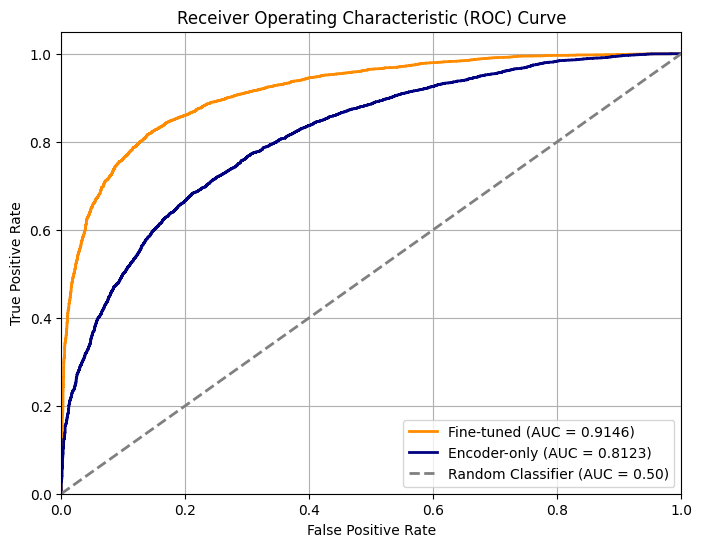

Fine-tuned Model AUC: 0.9146
Encoder-only Model AUC: 0.8123


In [7]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve and AUC for the Fine-tuned model
ft_fpr, ft_tpr, _ = roc_curve(y_true, ft_prob)
ft_roc_auc = auc(ft_fpr, ft_tpr)

# Calculate ROC curve and AUC for the Encoder-only model
enc_fpr, enc_tpr, _ = roc_curve(y_true, enc_prob)
enc_roc_auc = auc(enc_fpr, enc_tpr)

# Plotting the ROC curves
plt.figure(figsize=(8, 6))
plt.plot(ft_fpr, ft_tpr, color='darkorange', lw=2, label=f'Fine-tuned (AUC = {ft_roc_auc:.4f})')
plt.plot(enc_fpr, enc_tpr, color='navy', lw=2, label=f'Encoder-only (AUC = {enc_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"Fine-tuned Model AUC: {ft_roc_auc:.4f}")
print(f"Encoder-only Model AUC: {enc_roc_auc:.4f}")

In [8]:
preview = pd.DataFrame({
    "text": texts[:10],
    "label": y_true[:10],
    "fine_tuned_pred": ft_pred[:10],
    "encoder_only_pred": enc_pred[:10],
})
preview

,text,label,fine_tuned_pred,encoder_only_pred
0,the rock is destined to be the 21st century's ...,1,1,0
1,"the gorgeously elaborate continuation of "" the...",1,1,1
2,effective but too-tepid biopic,1,1,0
3,if you sometimes like to go to the movies to h...,1,1,1
4,"emerges as something rare , an issue movie tha...",1,1,1
5,the film provides some great insight into the ...,1,1,1
6,offers that rare combination of entertainment ...,1,1,1
7,perhaps no picture ever made has more literall...,1,1,1
8,steers turns in a snappy screenplay that curls...,1,1,1
9,take care of my cat offers a refreshingly diff...,1,1,1
